# House Price Prediction using Machine Learning

## Objective

The objective of this project is to predict the price of a house based on different features such as area, number of bedrooms, bathrooms, parking, and other amenities.

## Algorithm Used

- Linear Regression

## Tools Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv("Housing.csv")

# Display first five rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# Display first 5 rows
print("First 5 Rows:")
display(df.head())

# Display last 5 rows
print("\nLast 5 Rows:")
display(df.tail())

# Shape of dataset
print("\nShape of Dataset:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
display(df.describe())

First 5 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Last 5 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished



Shape of Dataset:
(545, 13)

Column Names:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea   

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


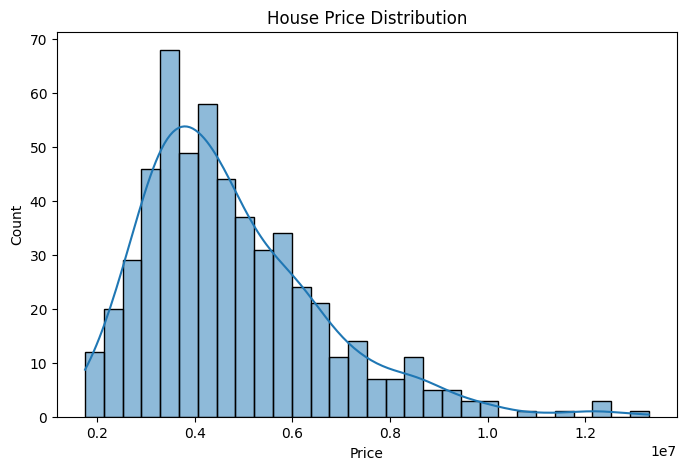

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

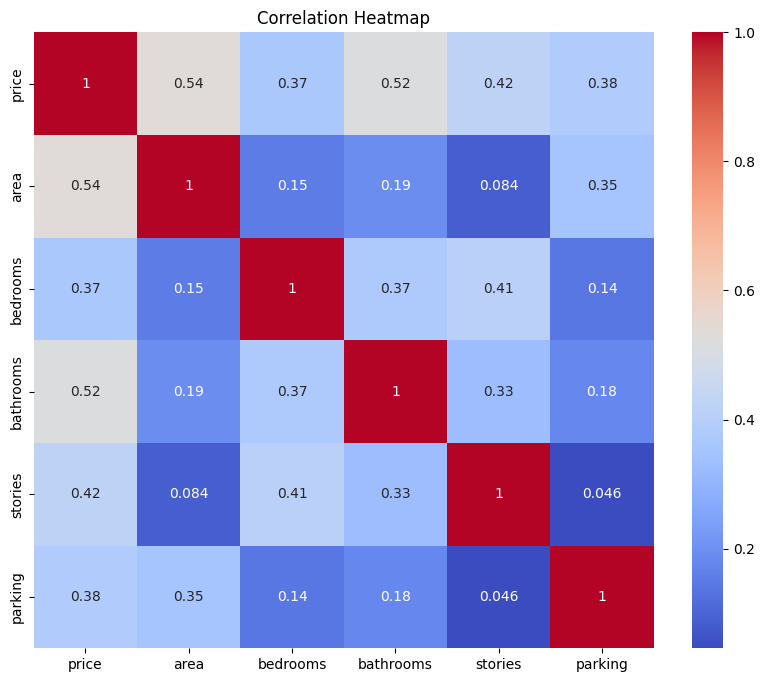

In [5]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [6]:
# Convert categorical columns into numerical values
df_encoded = pd.get_dummies(df, drop_first=True)

# Display first 5 rows
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [7]:
# Features (X)
X = df_encoded.drop("price", axis=1)

# Target (y)
y = df_encoded["price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 13)
Testing Data: (109, 13)


In [9]:
# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
# Predict house prices
y_pred = model.predict(X_test)

# Display first 10 predictions
prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

prediction_df.head(10)

,Actual Price,Predicted Price
0,4060000,5.164654e+06
1,6650000,7.224722e+06
2,3710000,3.109863e+06
3,6440000,4.612075e+06
4,2800000,3.294646e+06
5,4900000,3.532275e+06
6,5250000,5.611775e+06
7,4543000,6.368146e+06
8,2450000,2.722857e+06
9,3353000,2.629406e+06


In [11]:
# Import numpy if not already imported
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 970043.4
Mean Squared Error (MSE): 1754318687330.66
Root Mean Squared Error (RMSE): 1324506.96
R² Score: 0.6529


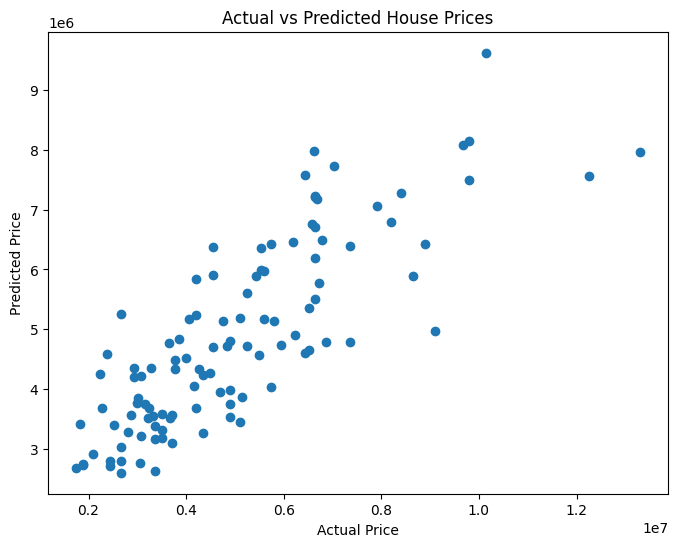

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [13]:
# Select the first house from the test set
sample_house = X_test.iloc[[0]]

# Predict its price
predicted_price = model.predict(sample_house)

print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))
print("Actual House Price:    ₹{:,.2f}".format(y_test.iloc[0]))

Predicted House Price: ₹5,164,653.90
Actual House Price:    ₹4,060,000.00


# Conclusion

In this project, we developed a House Price Prediction model using Linear Regression.

The dataset was explored, preprocessed, and categorical features were converted into numerical values using one-hot encoding. The data was then split into training and testing sets, and the Linear Regression model was trained successfully.

The model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. The results showed that the model can estimate house prices reasonably well based on the available features.

This project provided practical experience in regression, data preprocessing, model training, evaluation, and prediction using Python and Scikit-learn.
